# 02 — Coast-Down Segment Extraction & ODE Fit

Extract all coast-down segments from Canada 2026 FP sessions, fit α and β per segment,
and visualise fit quality and parameter scatter by active aero mode (straight / corner).

In [ ]:
import sys
sys.path.insert(0, '..')

import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from src.segments import extract_coastdown_segments, segment_active_aero_state
from src.ode_fit import v_model, fit_segment, FitResult
from src.aero_params import air_density, car_mass

fastf1.Cache.enable_cache('../cache')

## Driver survey — all FP sessions, all drivers

Find the driver with the most valid coast-down segments across the Canada 2026 weekend.

In [ ]:
import os, pickle

SURVEY_CACHE = '../results/survey_cache.pkl'
SURVEY_CIRCUITS = ['Canada']
SURVEY_SESSIONS = ['FP1', 'FP2', 'FP3']

if os.path.exists(SURVEY_CACHE):
    with open(SURVEY_CACHE, 'rb') as f:
        survey_data = pickle.load(f)
    survey_df = survey_data['survey_df']
    totals     = survey_data['totals']
    print('Loaded survey from cache.')
else:
    survey_rows = []

    for circuit in SURVEY_CIRCUITS:
        for session_name in SURVEY_SESSIONS:
            try:
                sess = fastf1.get_session(2026, circuit, session_name)
                sess.load(telemetry=True, weather=True)
            except Exception as e:
                print(f'Could not load {circuit} {session_name}: {e}')
                continue

            rho_s = air_density(sess.weather_data['AirTemp'].mean(), sess.weather_data['Pressure'].mean())

            for driver in sess.drivers:
                try:
                    laps = sess.laps.pick_drivers(driver)
                    laps = laps[laps['LapNumber'] > 1]
                except Exception:
                    continue

                n_segs, n_straight = 0, 0

                for _, lap in laps.iterrows():
                    lap_num = int(lap['LapNumber'])
                    m = car_mass(lap_num)
                    try:
                        tel = lap.get_telemetry()
                    except Exception:
                        continue

                    segs = extract_coastdown_segments(
                        tel, min_duration=0.5, min_speed_kmh=120.0, throttle_threshold=5.0,
                    )
                    for seg in segs:
                        straight_mode = segment_active_aero_state(seg)
                        result = fit_segment(seg, m, rho_s, straight_mode, lap_num)
                        if result is not None and result.r2 >= 0.90:
                            n_segs += 1
                            if straight_mode:
                                n_straight += 1

                if n_segs > 0:
                    survey_rows.append({
                        'circuit': circuit,
                        'session': session_name,
                        'driver': driver,
                        'n_segments': n_segs,
                        'n_straight_mode': n_straight,
                    })

    survey_df = pd.DataFrame(survey_rows).sort_values(
        ['n_straight_mode', 'n_segments'], ascending=False
    ).reset_index(drop=True)

    totals = (
        survey_df.groupby(['circuit', 'driver'])
        .agg(total_segments=('n_segments', 'sum'), total_straight_mode=('n_straight_mode', 'sum'))
        .sort_values(['total_straight_mode', 'total_segments'], ascending=False)
        .reset_index()
    )

    with open(SURVEY_CACHE, 'wb') as f:
        pickle.dump({'survey_df': survey_df, 'totals': totals}, f)
    print('Survey complete. Results cached.')

print(survey_df.to_string(index=False))
print('\n--- Totals across all FP sessions ---')
print(totals.to_string(index=False))

best_circuit = totals.iloc[0]['circuit']
best_driver  = totals.iloc[0]['driver']
print(f'\nSelected: {best_circuit} — driver {best_driver}  '
      f'({int(totals.iloc[0]["total_segments"])} segments, '
      f'{int(totals.iloc[0]["total_straight_mode"])} straight-mode)')

## Load session and select driver

In [3]:
print(f'Circuit: {best_circuit}')
print(f'Driver:  {best_driver}')
print('Pooling FP1, FP2, FP3')

Circuit: Monza
Driver:  14
Pooling FP1, FP2, FP3


## Extract coast-down segments across all laps

In [ ]:
all_results: list[FitResult] = []
all_segments_for_plot = []
rho_values = []

# β is fixed at the median from our earlier free fits (120 N → Crr ≈ 0.014).
# This breaks the α/β/P_mgu degeneracy and lets the pooled fit constrain α reliably.
BETA_FIXED = 120.0  # N

for session_name in ['FP1', 'FP2', 'FP3']:
    try:
        session = fastf1.get_session(2026, best_circuit, session_name)
        session.load(telemetry=True, weather=True)
    except Exception as e:
        print(f'Skipping {best_circuit} {session_name}: {e}')
        continue

    rho_s = air_density(session.weather_data['AirTemp'].mean(), session.weather_data['Pressure'].mean())
    rho_values.append(rho_s)

    laps = session.laps.pick_drivers(best_driver)
    laps_filtered = laps[laps['LapNumber'] > 1].copy()
    n_before = len(all_results)

    for _, lap in laps_filtered.iterrows():
        lap_num = int(lap['LapNumber'])
        m = car_mass(lap_num)
        try:
            tel = lap.get_telemetry()
        except Exception:
            continue

        segs = extract_coastdown_segments(
            tel, min_duration=0.5, min_speed_kmh=120.0, throttle_threshold=5.0,
        )
        for seg in segs:
            straight_mode = segment_active_aero_state(seg)
            result = fit_segment(seg, m, rho_s, straight_mode, lap_num, beta_fixed=BETA_FIXED)
            if result is not None and result.r2 >= 0.90:
                all_results.append(result)
                all_segments_for_plot.append((seg, result))

    print(f'{session_name}: {len(all_results) - n_before} segments')

rho = float(np.mean(rho_values))
print(f'\nTotal valid segments: {len(all_results)}')
straight_count = sum(r.straight_mode for r in all_results)
print(f'  Straight mode (active aero open): {straight_count}')
print(f'  Corner mode  (active aero closed): {len(all_results) - straight_count}')
print(f'Mean air density: {rho:.4f} kg/m³')
print(f'β fixed at: {BETA_FIXED} N  (Crr = {BETA_FIXED/(900*9.81):.4f})')

# Spot-check: print unique DRS channel values seen in a sample segment to verify 2026 encoding
if all_segments_for_plot:
    sample_seg = all_segments_for_plot[0][0]
    if 'DRS' in sample_seg.columns:
        print(f'\nDRS channel unique values in first segment: {sorted(sample_seg["DRS"].unique())}')
        print('(Values > 10 indicate active aero open / straight mode)')

## Visualise fit quality — sample of segments

## Residual analysis — model specification check

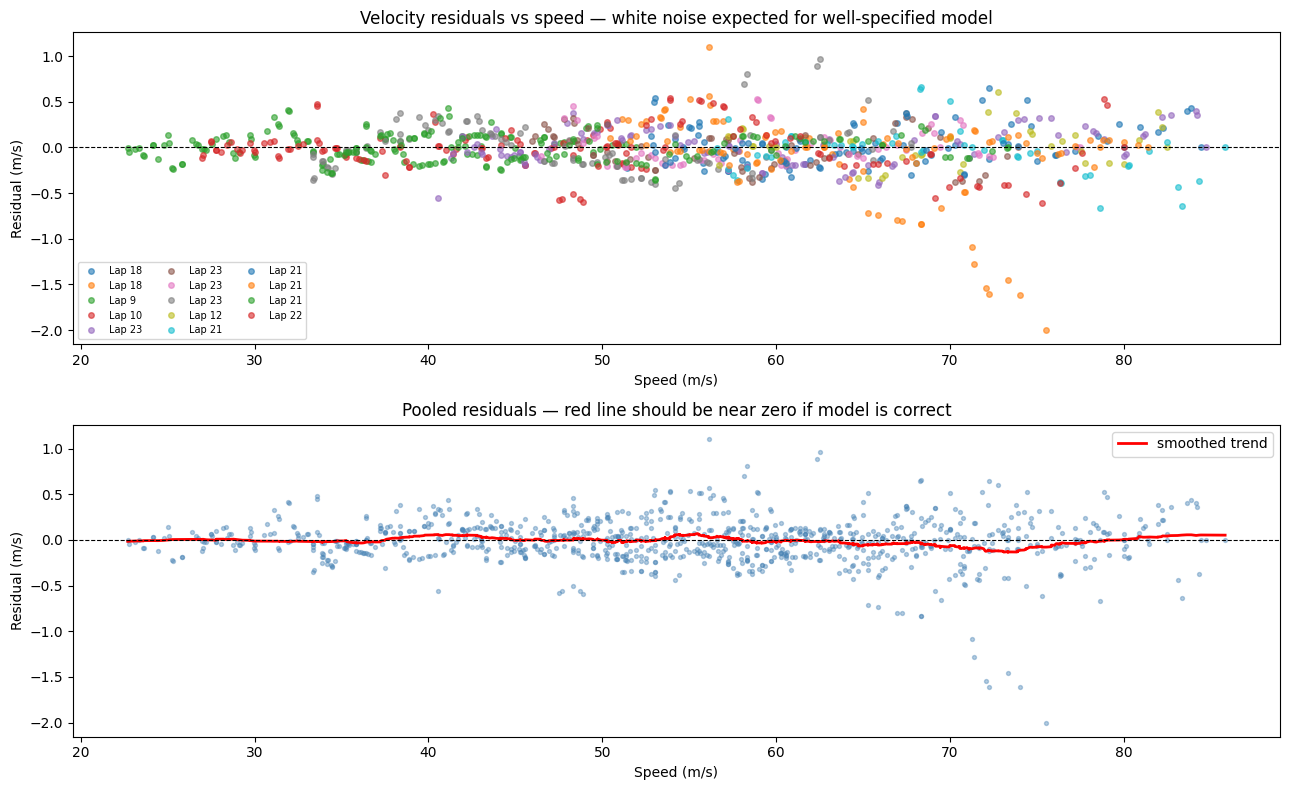


Durbin-Watson statistics per segment (2.0 = no autocorrelation):
  Lap 18: DW = 0.87  ⚠ autocorrelation
  Lap 18: DW = 0.21  ⚠ autocorrelation
  Lap 9: DW = 0.54  ⚠ autocorrelation
  Lap 10: DW = 0.90  ⚠ autocorrelation
  Lap 23: DW = 0.43  ⚠ autocorrelation
  Lap 23: DW = 0.49  ⚠ autocorrelation
  Lap 23: DW = 0.58  ⚠ autocorrelation
  Lap 23: DW = 0.72  ⚠ autocorrelation
  Lap 12: DW = 0.74  ⚠ autocorrelation
  Lap 21: DW = 0.79  ⚠ autocorrelation
  Lap 21: DW = 1.47  ⚠ autocorrelation
  Lap 21: DW = 0.70  ⚠ autocorrelation
  Lap 21: DW = 0.50  ⚠ autocorrelation
  Lap 22: DW = 0.24  ⚠ autocorrelation

Mean DW: 0.66


In [5]:
from statsmodels.stats.stattools import durbin_watson

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

all_speeds, all_resids = [], []
dw_stats = []

for seg, fit in all_segments_for_plot:
    t = seg['t'].values - seg['t'].values[0]
    v_meas = seg['Speed'].values / 3.6
    v_pred = v_model(t, fit.alpha, fit.beta, fit.P_mgu, fit.v0, fit.m)
    residuals = v_meas - v_pred

    axes[0].plot(v_meas, residuals, 'o', ms=4, alpha=0.6,
                 label=f'Lap {fit.lap_number}')
    all_speeds.extend(v_meas.tolist())
    all_resids.extend(residuals.tolist())
    dw_stats.append(durbin_watson(residuals))

axes[0].axhline(0, color='k', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Speed (m/s)')
axes[0].set_ylabel('Residual (m/s)')
axes[0].set_title('Velocity residuals vs speed — white noise expected for well-specified model')
axes[0].legend(fontsize=7, ncol=3)

# Pooled residuals with LOWESS trend to detect systematic shape
from scipy.ndimage import uniform_filter1d
idx = np.argsort(all_speeds)
v_sorted = np.array(all_speeds)[idx]
r_sorted = np.array(all_resids)[idx]
r_smooth = uniform_filter1d(r_sorted, size=max(3, len(r_sorted)//10))
axes[1].scatter(v_sorted, r_sorted, s=8, alpha=0.4, color='steelblue')
axes[1].plot(v_sorted, r_smooth, 'r-', lw=2, label='smoothed trend')
axes[1].axhline(0, color='k', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Speed (m/s)')
axes[1].set_ylabel('Residual (m/s)')
axes[1].set_title('Pooled residuals — red line should be near zero if model is correct')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/figures/02_residuals.png', dpi=150)
plt.show()

print(f'\nDurbin-Watson statistics per segment (2.0 = no autocorrelation):')
for i, (_, fit) in enumerate(all_segments_for_plot):
    flag = '✓' if 1.5 <= dw_stats[i] <= 2.5 else '⚠ autocorrelation'
    print(f'  Lap {fit.lap_number}: DW = {dw_stats[i]:.2f}  {flag}')
print(f'\nMean DW: {np.mean(dw_stats):.2f}')

In [ ]:
n_plot = min(9, len(all_segments_for_plot))
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes = axes.flatten()

for idx, (seg, fit) in enumerate(all_segments_for_plot[:n_plot]):
    ax = axes[idx]
    t = seg['t'].values - seg['t'].values[0]
    v_meas = seg['Speed'].values / 3.6
    t_dense = np.linspace(0, t[-1], 200)
    v_pred = v_model(t_dense, fit.alpha, fit.beta, fit.P_mgu, fit.v0, fit.m)

    ax.plot(t, v_meas, 'o', ms=3, label='measured')
    ax.plot(t_dense, v_pred, '-', label=f'fit R²={fit.r2:.3f}')
    mode_label = 'straight mode' if fit.straight_mode else 'corner mode'
    ax.set_title(f'Lap {fit.lap_number} — {mode_label}', fontsize=8)
    ax.set_xlabel('t (s)', fontsize=7)
    ax.set_ylabel('v (m/s)', fontsize=7)
    ax.legend(fontsize=6)

for idx in range(n_plot, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Coast-down fit quality — sample segments')
plt.tight_layout()
plt.savefig('../results/figures/02_fit_quality.png', dpi=150)
plt.show()

## α / β scatter by active aero mode

In [ ]:
alphas_corner   = [r.alpha for r in all_results if not r.straight_mode]
betas_corner    = [r.beta  for r in all_results if not r.straight_mode]
alphas_straight = [r.alpha for r in all_results if r.straight_mode]
betas_straight  = [r.beta  for r in all_results if r.straight_mode]
p_mgus          = [r.P_mgu for r in all_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(betas_corner,   alphas_corner,   alpha=0.6, label='corner mode',   color='steelblue')
ax.scatter(betas_straight, alphas_straight, alpha=0.6, label='straight mode', color='tomato')
ax.set_xlabel('β (N)')
ax.set_ylabel('α (N·s²/m²)')
ax.set_title('α vs β by active aero mode')
ax.legend()

ax = axes[1]
r2_values = [r.r2 for r in all_results]
ax.hist(r2_values, bins=20, edgecolor='black')
ax.set_xlabel('R²')
ax.set_ylabel('count')
ax.set_title('Fit quality distribution')

plt.tight_layout()
plt.savefig('../results/figures/02_alpha_beta_scatter.png', dpi=150)
plt.show()

print(f'Median α (corner mode):   {np.median(alphas_corner):.4f}'   if alphas_corner   else 'No corner-mode segments')
print(f'Median α (straight mode): {np.median(alphas_straight):.4f}' if alphas_straight else 'No straight-mode segments')
print(f'Median β (all):           {np.median(betas_corner + betas_straight):.1f} N')
print(f'Median P_mgu:             {np.median(p_mgus)/1000:.1f} kW  (expected 0–350 kW, 2026 MGU-K)')

## α vs lap number — fuel load sensitivity

In [ ]:
lap_nums = [r.lap_number for r in all_results]
alphas   = [r.alpha      for r in all_results]
colours  = ['tomato' if r.straight_mode else 'steelblue' for r in all_results]

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(lap_nums, alphas, c=colours, alpha=0.7, s=30)
ax.set_xlabel('Lap number')
ax.set_ylabel('α (N·s²/m²)')
ax.set_title('α vs lap number (blue=corner mode, red=straight mode)')
plt.tight_layout()
plt.savefig('../results/figures/02_alpha_vs_lap.png', dpi=150)
plt.show()

## Pooled fit — shared α across all segments

In [ ]:
from src.ode_fit import fit_segments_pooled

segs_pool  = [seg for seg, _ in all_segments_for_plot]
m_pool     = [r.m            for _, r in all_segments_for_plot]
aero_pool  = [r.straight_mode for _, r in all_segments_for_plot]
lap_pool   = [r.lap_number   for _, r in all_segments_for_plot]

print(f'Running pooled fit on {len(segs_pool)} segments (β fixed = {BETA_FIXED} N)...')
pooled_results = fit_segments_pooled(
    segs_pool, m_pool, aero_pool, lap_pool,
    seed_results=all_results,
    beta_fixed=BETA_FIXED,
)

if pooled_results is None:
    print('Pooled fit failed — keeping per-segment results.')
    alpha_p, alpha_std_p = float('nan'), float('nan')
else:
    alpha_p     = pooled_results[0].alpha
    alpha_std_p = pooled_results[0].alpha_std
    p_mgus_p    = [r.P_mgu / 1000 for r in pooled_results]

    print(f'\n=== Pooled fit results ===')
    print(f'α  = {alpha_p:.4f} ± {alpha_std_p:.4f}  (per-segment median: {np.median([r.alpha for r in all_results]):.4f})')
    print(f'β  = {BETA_FIXED:.1f} N (fixed)  →  Crr = {BETA_FIXED/(900*9.81):.4f}')
    print(f'P_mgu per segment (kW): {[f"{p:.1f}" for p in p_mgus_p]}')

    composite = 2.0 * alpha_p / rho
    print(f'\nComposite (2α/ρ) = {composite:.3f} m²')

    all_results = pooled_results
    print(f'\nall_results updated to pooled fit ({len(all_results)} segments)')

## Active aero ΔCdA — split-mode α comparison

In 2026 both straight-mode and corner-mode coast-down segments appear in the same FP
session.  Fitting α separately for each group gives a direct, within-car measurement
of the active aero drag reduction with no slipstream confound.

In [ ]:
straight_segs = [(seg, r) for seg, r in all_segments_for_plot if r.straight_mode]
corner_segs   = [(seg, r) for seg, r in all_segments_for_plot if not r.straight_mode]

def pool_mode(pairs, label):
    if len(pairs) < 2:
        print(f'{label}: only {len(pairs)} segment(s) — skipping pooled fit.')
        return None, float('nan'), float('nan')
    s  = [seg for seg, _ in pairs]
    ms = [r.m            for _, r in pairs]
    st = [r.straight_mode for _, r in pairs]
    ln = [r.lap_number   for _, r in pairs]
    res = fit_segments_pooled(s, ms, st, ln, beta_fixed=BETA_FIXED)
    if res is None:
        print(f'{label}: pooled fit failed.')
        return None, float('nan'), float('nan')
    a = res[0].alpha
    a_std = res[0].alpha_std
    comp = 2.0 * a / rho
    print(f'{label}: α = {a:.4f} ± {a_std:.4f}  composite 2α/ρ = {comp:.3f} m²  ({len(pairs)} segs)')
    return res, a, a_std

print('=== Per-mode pooled fits ===')
res_straight, alpha_straight, alpha_straight_std = pool_mode(straight_segs, 'Straight mode')
res_corner,   alpha_corner,   alpha_corner_std   = pool_mode(corner_segs,   'Corner mode  ')

if np.isfinite(alpha_straight) and np.isfinite(alpha_corner):
    delta_alpha = alpha_corner - alpha_straight          # positive = corner has more drag
    delta_CdA   = 2.0 * delta_alpha / rho               # m²
    delta_CdA_std = 2.0 / rho * np.sqrt(alpha_straight_std**2 + alpha_corner_std**2)

    print(f'\n=== Active aero drag delta ===')
    print(f'Δα = α_corner − α_straight = {delta_alpha:.4f}')
    print(f'ΔCdA (straight − corner)   = {-delta_CdA:.3f} ± {delta_CdA_std:.3f} m²')
    print(f'Expected (2026 active aero): −0.5 to −1.2 m²')

    fig, ax = plt.subplots(figsize=(7, 5))
    labels = ['Corner mode\n(high downforce)', 'Straight mode\n(low drag)']
    alphas_bar = [alpha_corner, alpha_straight]
    errs_bar   = [alpha_corner_std, alpha_straight_std]
    bars = ax.bar(labels, alphas_bar, yerr=errs_bar, capsize=8,
                  color=['steelblue', 'tomato'], width=0.5)
    ax.set_ylabel('Pooled α (N·s²/m²)')
    ax.set_title('Active aero mode comparison — Canada 2026')
    for bar, val, err in zip(bars, alphas_bar, errs_bar):
        ax.text(bar.get_x() + bar.get_width()/2, val + err + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig('../results/figures/02_active_aero_delta.png', dpi=150)
    plt.show()
else:
    print('\nCannot compute ΔCdA — need segments in both modes.')

## Miami cross-validation

Repeat the coast-down fit on Miami 2026 FP data and compare α to Canada.
The ratio α_Miami / α_Canada reflects the relative aerodynamic drag between the
two circuits (different setups, similar car spec).

In [ ]:
miami_totals = totals[totals['circuit'] == 'Miami'].sort_values('total_segments', ascending=False)
if miami_totals.empty:
    print('No Miami data in survey — delete survey cache and re-run with SURVEY_CIRCUITS = ["Canada", "Miami"].')
elif not np.isfinite(alpha_p):
    print('Pooled fit failed — skipping Miami validation.')
else:
    miami_driver = str(miami_totals.iloc[0]['driver'])
    print(f'Miami validation — driver {miami_driver}')

    miami_results = []
    for session_name in ['FP1', 'FP2', 'FP3']:
        try:
            sess = fastf1.get_session(2026, 'Miami', session_name)
            sess.load(telemetry=True, weather=True)
        except Exception as e:
            print(f'  Skipping Miami {session_name}: {e}')
            continue

        rho_miami = air_density(sess.weather_data['AirTemp'].mean(), sess.weather_data['Pressure'].mean())
        laps_m = sess.laps.pick_drivers(miami_driver)
        laps_m = laps_m[laps_m['LapNumber'] > 1]

        for _, lap in laps_m.iterrows():
            lap_num = int(lap['LapNumber'])
            m = car_mass(lap_num)
            try:
                tel = lap.get_telemetry()
            except Exception:
                continue
            segs = extract_coastdown_segments(tel, min_duration=0.5, min_speed_kmh=120.0, throttle_threshold=5.0)
            for seg in segs:
                straight_mode = segment_active_aero_state(seg)
                r = fit_segment(seg, m, rho_miami, straight_mode, lap_num, beta_fixed=BETA_FIXED)
                if r is not None and r.r2 >= 0.90:
                    miami_results.append(r)

    if miami_results:
        alpha_miami_median = np.median([r.alpha for r in miami_results])
        print(f'\nMiami per-segment α median: {alpha_miami_median:.4f}  ({len(miami_results)} segments)')
        print(f'Canada pooled α:             {alpha_p:.4f}')
        ratio = alpha_miami_median / alpha_p
        print(f'Ratio Miami/Canada: {ratio:.2f}  (expected ~1.0–1.3; Miami typically higher-downforce setup)')
    else:
        print('No valid Miami segments found after quality filter.')

In [11]:
import pickle
with open('../results/fit_results.pkl', 'wb') as f:
    pickle.dump({'results': all_results, 'rho': rho, 'driver': best_driver}, f)
print('Saved fit_results.pkl')

Saved fit_results.pkl
